In [ ]:
!pip install e2b-code-interpreter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.7/81.7 kB 2.2 MB/s eta 0:00:00


In [ ]:
from e2b_code_interpreter import Sandbox
from google.colab import userdata

sbx = Sandbox(
    api_key = userdata.get("E2B_API_KEY"),
    template = "desktop"
) # By default the sandbox is alive for 5 minutes

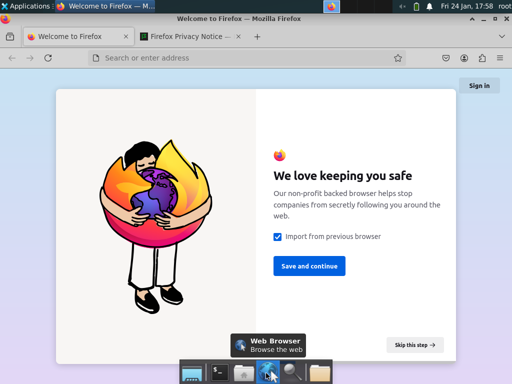

In [ ]:
screenshot_path = "screenshot.png"
sbx.commands.run(f"scrot --pointer {screenshot_path}")
screenshot = sbx.files.read(screenshot_path, format="bytes")
sbx.files.remove(screenshot_path)

from io import BytesIO
from PIL import Image as PILImage
from IPython.display import display

img = PILImage.open(BytesIO(screenshot))

width, height = img.size
new_width = int(width * 0.5)
new_height = int(height * 0.5)
small_img = img.resize((new_width, new_height))

display(small_img)

img.save("screenshot.png")

In [ ]:
sbx.commands.run("xdotool mousemove --sync 550 750")

CommandResult(stderr='', stdout='', exit_code=0, error='')

In [ ]:
sbx.commands.run("xdotool click 1")

CommandResult(stderr='', stdout='', exit_code=0, error='')

In [ ]:
from openai import OpenAI

client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=userdata.get("GROQ_API_KEY")
)

tools = [{
    "type": "function",
    "function": {
        "name": "click_mouse",
        "description": "Click on an item on the screen.",
        "parameters": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "A description of what you want to click on"
                }
            },
            "required": [
                "query"
            ],
            "additionalProperties": False
        },
        "strict": True
    }
}]

import base64

base64_screenshot = base64.b64encode(screenshot).decode("utf-8")

completion = client.chat.completions.create(
    model="llama-3.2-90b-vision-preview",
    messages=[
        {"role": "user", "content": [
            {"type":"image_url", "image_url":{"url": f"data:image/jpeg;base64,{base64_screenshot}"}},
            {"type":"text", "text":"Here are the contents of the screen."},
            {"type":"text", "text":"The objective is: Check the weather using the web browser?"},
        ]}
    ],
    tools=tools
)

print(completion.choices[0].message.content)
print(completion.choices[0].message.tool_calls)

None
[ChatCompletionMessageToolCall(id='call_h5m9', function=Function(arguments='{"query": "web browser"}', name='click_mouse'), type='function')]


In [ ]:
base64_screenshot

'...'

In [ ]:
!pip install gradio_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.8/321.8 kB 5.1 MB/s eta 0:00:00


In [ ]:
from gradio_client import Client, handle_file

OSATLAS_HUGGINGFACE_SOURCE = "maxiw/OS-ATLAS"
OSATLAS_HUGGINGFACE_MODEL = "OS-Copilot/OS-Atlas-Base-7B"
OSATLAS_HUGGINGFACE_API = "/run_example"

huggingface_client = Client(OSATLAS_HUGGINGFACE_SOURCE)



Loaded as API: https://maxiw-os-atlas.hf.space ✔
('Web browser', '[[512.0, 724.992, 553.984, 768.0]]', '/tmp/gradio/195373f91269cb88507b9ad1193298a148598b286633e616f02b8c1cffc4ee28/image.webp')


In [ ]:
import re

result = huggingface_client.predict(
    image=handle_file("screenshot.png"),
    text_input= "Web browser" + "\nReturn the response in the form of a bbox",
    model_id=OSATLAS_HUGGINGFACE_MODEL,
    api_name=OSATLAS_HUGGINGFACE_API,
)
print(result)

numbers = [float(number) for number in re.findall(r"\d+\.\d+", result[1])]
# x1, y1, x2, y2

result_x, result_y = (numbers[0] + numbers[2]) // 2, (numbers[1] + numbers[3]) // 2
result_x, result_y

(532.0, 746.0)

In [ ]:
sbx.commands.run(f"xdotool mousemove --sync {result_x} {result_y}")
sbx.commands.run("xdotool click 1")

CommandResult(stderr='', stdout='', exit_code=0, error='')

In [ ]:
import re

def get_coordinates(query):

  result = huggingface_client.predict(
      image=handle_file("screenshot.png"),
      text_input= "Web browser" + "\nReturn the response in the form of a bbox",
      model_id=OSATLAS_HUGGINGFACE_MODEL,
      api_name=OSATLAS_HUGGINGFACE_API,
  )
  print(result)

  numbers = [float(number) for number in re.findall(r"\d+\.\d+", result[1])]
  # x1, y1, x2, y2

  result_x, result_y = (numbers[0] + numbers[2]) // 2, (numbers[1] + numbers[3]) // 2
  return result_x, result_y

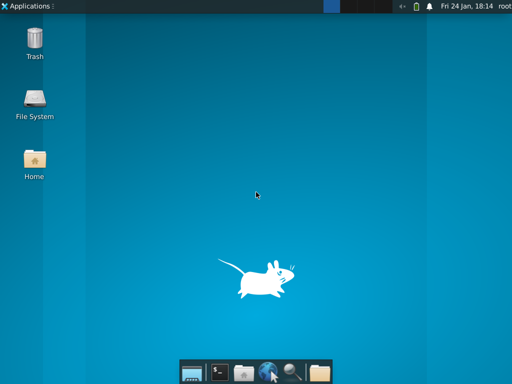

None
[ChatCompletionMessageToolCall(id='call_cv40', function=Function(arguments='{"query": "Internet browser"}', name='click_mouse'), type='function')]
Internet browser
('web browser', '[[512.0, 724.992, 553.984, 768.0]]', '/tmp/gradio/c7a71e2d59d967b74aa50367aee73219854c4a34f026b15b393b75a7c42d912d/image.webp')
532.0 746.0


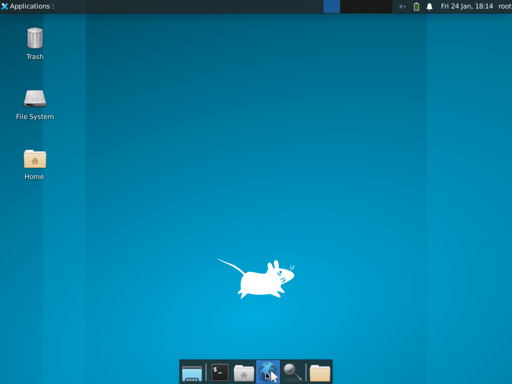

None
[ChatCompletionMessageToolCall(id='call_8g3h', function=Function(arguments='{"query": "Web Browser icon"}', name='click_mouse'), type='function')]
Web Browser icon
('Web browser', '[[512.0, 718.08, 559.104, 768.0]]', '/tmp/gradio/f9405c7a55098cd8d7572ff912c7213595b7f8ad7ba3b7223abbd152a29e8f41/image.webp')
535.0 743.0


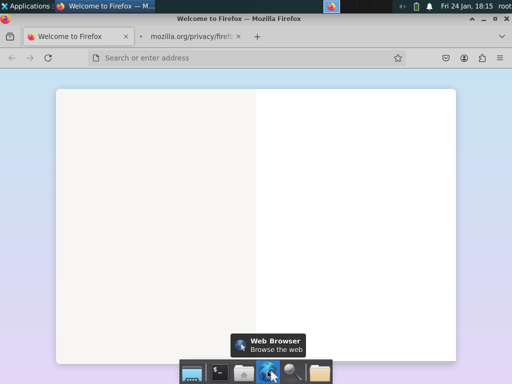

None
[ChatCompletionMessageToolCall(id='call_1q35', function=Function(arguments='{"query": "Web Browser"}', name='click_mouse'), type='function')]
Web Browser
('Web browser', '[[459.776, 667.392, 610.304, 712.7040000000001]]', '/tmp/gradio/5dbc41323893e6087d2dad8fc5232b23fb4ada5db1f38e903847da4537f23009/image.webp')
535.0 690.0


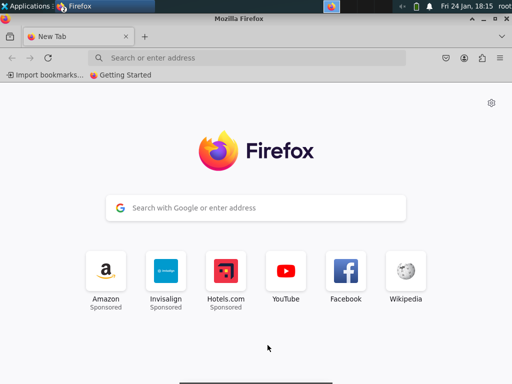

None
[ChatCompletionMessageToolCall(id='call_d2h0', function=Function(arguments='{"query": "web browser"}', name='click_mouse'), type='function')]
web browser
('Web browser', '[[0.0, 0.0, 311.296, 29.952]]', '/tmp/gradio/2ff80cdc3f1138fda4751109827793c63b587cc23395cd40c077f5f97074ceb1/image.webp')
155.0 14.0


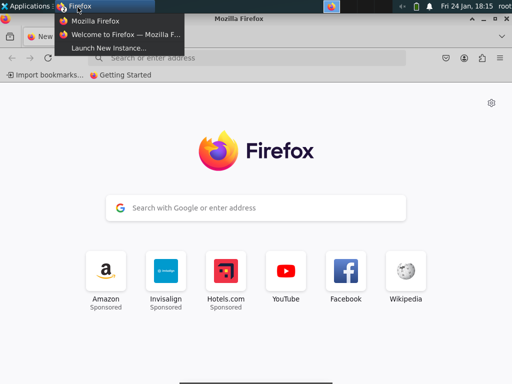

None
[ChatCompletionMessageToolCall(id='call_52bn', function=Function(arguments='{"query": "Web browser icon"}', name='click_mouse'), type='function'), ChatCompletionMessageToolCall(id='call_45hd', function=Function(arguments='{"query": "Search bar"}', name='click_mouse'), type='function'), ChatCompletionMessageToolCall(id='call_h60y', function=Function(arguments='{"query": "Search for weather"}', name='click_mouse'), type='function')]
Web browser icon
('Web browser', '[[0.0, 0.0, 1024.0, 767.232]]', '/tmp/gradio/1bc8c56e7200e76a9f22230a1a04586d3a6522dbc1109fe8bb019b2eb7e90680/image.webp')
512.0 383.0


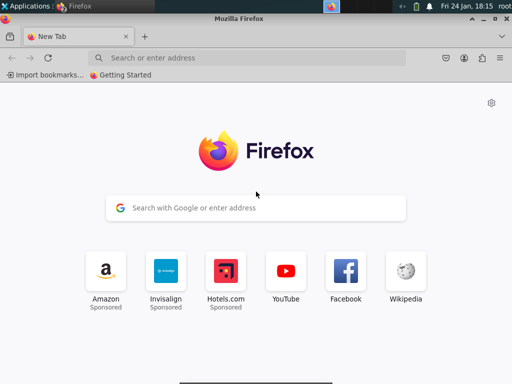

<function=click_mouse>{"query": "New Tab"}<function=click_mouse>{"query": "Amazon Sponsored"}<function=click_mouse>{"query": "Invisalign Sponsored"}<function=click_mouse>{"query": "Hotels.com Sponsored"}<function=click_mouse>{"query": "YouTube"}<function=click_mouse>{"query": "Facebook"}<function=click_mouse>{"query": "Wikipedia"}<function=click_mouse>{"query": "weather"}<function=click_mouse>{"query": "search icon"}<function=click_mouse>{"query": "settings"}<function=click_mouse>{"query": "refresh"}<function=click_mouse>{"query": "back arrow"}<function=click_mouse>{"query": "forward arrow"}<function=click_mouse>{"query": "print"}<function=click_mouse>{"query": "save"}<function=click_mouse>{"query": "share"}<function=click_mouse>{"query": "download"}<function=click_mouse>{"query": "copy link"}<function=click_mouse>{"query": "open in new tab"}<function=click_mouse>{"query": "open in new window"}<function=click_mouse>{"query": "open in incognito"}<function=click_mouse>{"query": "open in 

In [ ]:
import base64
import json
import time

while True:

  # Getting the screenshot

  screenshot_path = "screenshot.png"
  sbx.commands.run(f"scrot --pointer {screenshot_path}")
  screenshot = sbx.files.read(screenshot_path, format="bytes")
  sbx.files.remove(screenshot_path)

  from io import BytesIO
  from PIL import Image as PILImage
  from IPython.display import display

  img = PILImage.open(BytesIO(screenshot))

  width, height = img.size
  new_width = int(width * 0.5)
  new_height = int(height * 0.5)
  small_img = img.resize((new_width, new_height))

  display(small_img)

  img.save("screenshot.png")

  base64_screenshot = base64.b64encode(screenshot).decode("utf-8")

  # Asking the LLM

  completion = client.chat.completions.create(
      model="llama-3.2-90b-vision-preview",
      messages=[
          {"role": "user", "content": [
              {"type":"image_url", "image_url":{"url": f"data:image/jpeg;base64,{base64_screenshot}"}},
              {"type":"text", "text":"Here are the contents of the screen."},
              {"type":"text", "text":"The objective is: Check the weather using the web browser?"},
          ]}
      ],
      tools=tools
  )

  print(completion.choices[0].message.content)
  print(completion.choices[0].message.tool_calls)

  tool_calls = completion.choices[0].message.tool_calls

  # Running the tool

  if tool_calls:
    tool_call = tool_calls[0]
    function_name = tool_call.function.name
    if function_name == "click_mouse":
      query = json.loads(tool_call.function.arguments)["query"]
      print(query)
      result_x, result_y = get_coordinates(query)
      print(result_x, result_y)
      sbx.commands.run(f"xdotool mousemove --sync {result_x} {result_y}")
      sbx.commands.run("xdotool click 1")
      time.sleep(1)
  else:
    break